In [1]:
# WHETHER TO COMMENT

import numpy as np
import matplotlib.pyplot as plt

import csv

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

from sklearn.linear_model import LinearRegression

import sklearn
from sklearn import datasets

import skimage


import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np


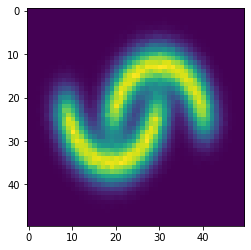

In [2]:
# two moon 

# producing matching results

# Neural Networks

X, y = make_moons(n_samples=1000000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train = X_train-X_train.min(0)
X_train = X_train/X_train.max(0)

# Define the range for both axes
axis_range = [(0, 1), (0, 1)]

# Define the number of bins
bins = 50

# Calculate the 2D histogram and return the matrix of histogram values
hist, xedges, yedges = np.histogram2d(X_train[:, 0], X_train[:, 1], bins=bins, range=axis_range, density=True)

# Normalize the histogram to make it a PDF
pdf = hist / np.sum(hist)
pdf = torch.from_numpy(pdf.T)

plt.imshow(pdf)
plt.show()

# run_dataset.append(X_train[:100000])
# pdf_list.append(pdf)

In [4]:
class encoder(nn.Module):
    def __init__(self, input_dim = 784, HIDDEN = 2000, out_dim = 200):
        super(encoder, self).__init__()
        self.dim = out_dim
    
        self.fc1 = nn.Linear(input_dim+5, HIDDEN, bias=True)
        self.ln1 = torch.nn.LayerNorm(HIDDEN)
        self.fc2 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.ln2 = torch.nn.LayerNorm(HIDDEN)
        self.fc3 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.ln3 = torch.nn.LayerNorm(HIDDEN)
        self.fc4 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.ln4 = torch.nn.LayerNorm(HIDDEN)
        self.fc6 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.ln6 = torch.nn.LayerNorm(HIDDEN)
        self.fc7 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.ln7 = torch.nn.LayerNorm(HIDDEN)
        self.fc8 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.ln8 = torch.nn.LayerNorm(HIDDEN)
        self.fc9 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.ln9 = torch.nn.LayerNorm(HIDDEN)

        self.fc5 = nn.Linear(HIDDEN, out_dim, bias=True)

    def forward(self, x):
        
        x = torch.cat((x, torch.zeros((x.shape[0], 5)).uniform_().cuda()), 1)
        x = torch.relu(self.ln1((self.fc1(x))))
        x = torch.relu(self.ln2((self.fc2(x))))
        x = torch.relu(self.ln3((self.fc3(x))))
        x = torch.relu(self.ln6((self.fc6(x))))
        x = torch.relu(self.ln7((self.fc7(x))))

        x = torch.sigmoid(self.fc5(x))

        return x

In [5]:
class encoder(nn.Module):
    def __init__(self, input_dim = 784, HIDDEN = 500, out_dim = 200):
        super(encoder, self).__init__()
        self.dim = out_dim
    
        self.fc1 = nn.Linear(input_dim+5, HIDDEN, bias=True)
        self.bn1 = torch.nn.BatchNorm1d(HIDDEN)
        self.fc2 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.bn2 = torch.nn.BatchNorm1d(HIDDEN)
        self.fc3 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.bn3 = torch.nn.BatchNorm1d(HIDDEN)
        self.fc4 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.bn4 = torch.nn.BatchNorm1d(HIDDEN)
        self.fc6 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.bn6 = torch.nn.BatchNorm1d(HIDDEN)
        self.fc7 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.bn7 = torch.nn.BatchNorm1d(HIDDEN)

        self.fc5 = nn.Linear(HIDDEN, out_dim, bias=True)

    def forward(self, x):
        
        x = torch.cat((x, torch.zeros((x.shape[0], 5)).uniform_().cuda()), 1)
        x = torch.relu(self.bn1((self.fc1(x))))
        x = torch.relu(self.bn2((self.fc2(x))))
        x = torch.relu(self.bn3((self.fc3(x))))
        x = torch.relu(self.bn4((self.fc4(x))))
        x = torch.relu(self.bn6((self.fc6(x))))

        x = torch.sigmoid(self.fc5(x))

        return x

In [ ]:
# THE DEPENDENCE APPROACH

torch.cuda.set_device(1)

def gauss(A,B,var):
    return torch.exp(-((A.unsqueeze(1) - B.unsqueeze(0))**2).mean(2)/(2*var))

def set_requires_grad(model, flag=True):
    for p in model.parameters():
        p.requires_grad = flag

torch.manual_seed(0)
np.random.seed(0)

E = encoder(input_dim = 2, out_dim = 1).cuda()

NET_F = encoder(input_dim = 2, out_dim = 15).cuda()
NET_G = encoder(input_dim = 1, out_dim = 15).cuda()

optimizer_E = optim.Adam([
      {'params': E.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

optimizer_F = optim.Adam([
      {'params': NET_F.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

optimizer_G = optim.Adam([
      {'params': NET_G.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

error_curve = []
eig_curve = []

for i in range(0, 200001):
    
    b1 = np.random.choice(train_data.shape[0], 2000)
    batch_data = torch.from_numpy(train_data[b1]).float().cuda()
    encoded = E(batch_data)
    
    var_x, var_y = 0.001, 0.001
    
    noise_data = batch_data + torch.zeros((batch_data.shape)).cuda().normal_()*np.sqrt(var_x)
    noise_code = encoded + torch.zeros((encoded.shape)).cuda().normal_()*np.sqrt(var_y)
    
    f = NET_F(noise_data)
    g = NET_G(noise_code)
    
    RF = f.T@f/f.shape[0]
    RG = g.T@g/g.shape[0]
    P = f.T@g/f.shape[0]
    
    RF = RF + torch.eye(RF.shape[0]).cuda()*1e-3
    RG = RG + torch.eye(RG.shape[0]).cuda()*1e-3
    
    cost = torch.trace(torch.inverse(RF)@P@torch.inverse(RG)@P.T)
    (-cost).backward()
    
#     dim = 30
#     RFG = torch.zeros((dim*2, dim*2)).cuda()
#     RFG[:dim, :dim] = RF
#     RFG[dim:, dim:] = RG
#     RFG[:dim, dim:] = P
#     RFG[dim:, :dim] = P.T
    
#     cost = torch.logdet(RFG) - torch.logdet(RF) - torch.logdet(RG)
#     (cost).backward()

    error_curve.append(cost.item())
    
    
    
    with torch.no_grad():
        Sigma, Q = torch.linalg.eigh(RF) 
        RF_NORM = (Q@torch.diag(Sigma**(-1/2))@Q.T) 

        Sigma, Q = torch.linalg.eigh(RG) 
        RG_NORM = (Q@torch.diag(Sigma**(-1/2))@Q.T) 

        P_STAR = RF_NORM@P@RG_NORM    
        U,S,V = torch.svd(P_STAR)

    eig_curve.append(S.detach().cpu().numpy())
    
    
    
    optimizer_E.step()
    optimizer_D.step()
    optimizer_F.step()
    optimizer_G.step()

    optimizer_E.zero_grad()
    optimizer_D.zero_grad()
    optimizer_F.zero_grad()
    optimizer_G.zero_grad()
    
    if i%100 == 0:
        print(i, cost.item())
        
        if i % 1000 == 0:
            E.eval()

            xx = np.linspace(0, 1, 50)
            yy = np.linspace(0, 1, 50)
            XX, YY = np.meshgrid(xx, yy)

            grid_points = torch.from_numpy(np.column_stack([XX.ravel(), YY.ravel()]))
            outputs = E(grid_points.cuda().float()).detach().cpu().numpy()

            plt.figure(figsize=(3, 3))
            plt.imshow(-outputs.reshape(50, 50), extent=[0, 1, 0, 1], origin='lower', cmap='coolwarm')
            plt.show()
            E.train()
            
            if i%1000 == 0:
                plt.figure(figsize=(3, 3))
                plt.plot(eig_curve)
                plt.show()
                
                
                
                
                
                
                Sigma, Q = torch.linalg.eigh(RF) 
                RF_NORM = (Q@torch.diag(Sigma**(-1/2))@Q.T) 

                Sigma, Q = torch.linalg.eigh(RG) 
                RG_NORM = (Q@torch.diag(Sigma**(-1/2))@Q.T) 

                P_STAR = RF_NORM@P@RG_NORM    
                U,S,V = torch.svd(P_STAR)

                NET_F.eval()

                xx = np.linspace(0, 1, 50)
                yy = np.linspace(0, 1, 50)
                XX, YY = np.meshgrid(xx, yy)

                grid_points = torch.from_numpy(np.column_stack([XX.ravel(), YY.ravel()]))
                decoded = NET_F(grid_points.cuda().float())

                to_visual = decoded@RF_NORM@U

                from torchvision.utils import save_image, make_grid

                plt.figure(figsize=(5, 5))
                save_image((to_visual.reshape(50, 50, -1).detach().cpu()*pdf.reshape(50, 50, -1).sqrt()).permute(2, 0, 1).unsqueeze(1)[:15], 'img_original.png', nrow=5, normalize=True, padding=1, pad_value=0)
                img = plt.imread('img_original.png')
                plt.imshow(img[:, :, 0], alpha=1, zorder=111, cmap='RdBu_r')
                plt.axis('off')
                plt.show()

                NET_F.train()

In [ ]:
# THE KDE APPROACH


torch.cuda.set_device(7)

def gauss(A,B,var):
    return torch.exp(-((A.unsqueeze(1) - B.unsqueeze(0))**2).mean(2)/(2*var))

def set_requires_grad(model, flag=True):
    for p in model.parameters():
        p.requires_grad = flag

torch.manual_seed(0)
np.random.seed(0)

E = encoder(input_dim = 2, out_dim = 1).cuda()
D = encoder(input_dim = 1, out_dim = 30).cuda()

optimizer_E = optim.Adam([
      {'params': E.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

optimizer_D = optim.Adam([
      {'params': D.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

error_curve = []
eig_curve = []

for i in range(0, 200001):
    
    b1 = np.random.choice(train_data.shape[0], 20000)
    batch_data = torch.from_numpy(train_data[b1]).float().cuda()
    
    encoded = E(batch_data)

    
    var_x, var_y = 0.001, 0.001
    
    noise_data = batch_data + torch.zeros((batch_data.shape)).cuda().normal_()*np.sqrt(var_x)
    noise_code = encoded + torch.zeros((encoded.shape)).cuda().normal_()*np.sqrt(var_y)
    
    combined = torch.cat((batch_data, encoded), 1)
    noise_combined = torch.cat((noise_data, noise_code), 1)

    
    L2_data = -((batch_data.unsqueeze(1) - noise_data.unsqueeze(0))**2).sum(-1)/(2*var_x)
    L2_codes = -((encoded.unsqueeze(1) - noise_code.unsqueeze(0))**2).sum(-1)/(2*var_y)
    
    pxy = torch.exp(L2_data+L2_codes).mean(0)
    px = torch.exp(L2_data).mean(0)
    py = torch.exp(L2_codes).mean(0)
    
#     pxy = torch.exp(-((combined.unsqueeze(1) - noise_combined.unsqueeze(0))**2).sum(-1)/(2*0.001)).mean(0)
#     py = torch.exp(-((encoded.unsqueeze(1) - noise_code.unsqueeze(0))**2).sum(-1)/(2*0.001)).mean(0)
#     px = torch.exp(-((batch_data.unsqueeze(1) - noise_data.unsqueeze(0))**2).sum(-1)/(2*0.001)).mean(0)
    
#     pxy = pxy*(1/(2*np.pi*0.001)**(3/2))
#     py = py*(1/(2*np.pi*0.001)**(1/2))
#     px = px*(1/(2*np.pi*0.001)**(2/2))

    pdf_error = (pxy/(px*py)).mean()
    (-pdf_error).backward()

    
    
    optimizer_E.step()
    optimizer_E.zero_grad()

    if i%100 == 0:
        print(pdf_error.item())
        
        if i % 1000 == 0:
            E.eval()

            xx = np.linspace(0, 1, 50)
            yy = np.linspace(0, 1, 50)
            XX, YY = np.meshgrid(xx, yy)

            grid_points = torch.from_numpy(np.column_stack([XX.ravel(), YY.ravel()]))
            outputs = E(grid_points.cuda().float()).detach().cpu().numpy()

#             plt.figure(figsize=(3, 3))
#             plt.imshow(-outputs.reshape(50, 50), extent=[0, 1, 0, 1], origin='lower', cmap='coolwarm')
#             plt.show()
#             D.train()

            plt.figure(figsize=(3, 3))
            plt.imshow(-outputs.reshape(50, 50), cmap='coolwarm')
            plt.show()
            D.train()


            E.train()

In [ ]:
# REGULAR AUTOENCODER

torch.cuda.set_device(7)

def gauss(A,B,var):
    return torch.exp(-((A.unsqueeze(1) - B.unsqueeze(0))**2).mean(2)/(2*var))

def set_requires_grad(model, flag=True):
    for p in model.parameters():
        p.requires_grad = flag

torch.manual_seed(0)
np.random.seed(0)

E = encoder(input_dim = 2, out_dim = 1).cuda()
D = encoder(input_dim = 1, out_dim = 2).cuda()

optimizer_E = optim.Adam([
      {'params': E.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

optimizer_D = optim.Adam([
      {'params': D.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

error_curve = []
eig_curve = []

for i in range(0, 200001):
    
    b1 = np.random.choice(train_data.shape[0], 5000)
    batch_data = torch.from_numpy(train_data[b1]).float().cuda()
    
    code = E(batch_data)
    reconstruct = D(code)
            
    error = ((reconstruct - batch_data)**2).mean(0).sum()
    (error).backward()
    
    optimizer_E.step()
    optimizer_D.step()

    optimizer_E.zero_grad()
    optimizer_D.zero_grad()

    if i%100 == 0:
        print(error.item())
                
        if i%1000 == 0:
            plt.figure(figsize=(3, 3))
            plt.scatter(reconstruct[:,0].detach().cpu(), reconstruct[:,1].detach().cpu(), s=1)
            plt.show()

In [ ]:
plt.figure(figsize=(3, 3))
plt.scatter(reconstruct.detach().cpu()[:, 0], reconstruct.detach().cpu()[:, 1], s=1)
plt.show()

In [ ]:
# REGULAR AUTOENCODER WITH A CHANGEABLE VARIANCE, DO A SEARCH TO FIND THE OPTIMAL VARIANCE


def find_optimal_variance():

    E.eval()
    D.eval()

    error_var_list = []

    with torch.no_grad():

        for variance in np.linspace(0.0001, .005, 100):

                var = torch.zeros((mean.shape)).fill_(variance).cuda().float()

                L_2  = (batch_data - mean)**2
                L_2 = L_2/(2*var)
                L_2 = L_2.sum(-1)

                error = L_2.mean() + torch.log(2*np.pi*((var[..., 0]*var[..., 1]).sqrt())).mean()
                error_var_list.append(error.item())

    var_optimal = np.linspace(0.0001, .005, 100)[np.argmin(error_var_list)]
    
    E.train()
    D.train()
    
    return var_optimal

# var_optimal = find_optimal_variance()

torch.cuda.set_device(7)

def gauss(A,B,var):
    return torch.exp(-((A.unsqueeze(1) - B.unsqueeze(0))**2).mean(2)/(2*var))

def set_requires_grad(model, flag=True):
    for p in model.parameters():
        p.requires_grad = flag

torch.manual_seed(0)
np.random.seed(0)

E = encoder(input_dim = 2, out_dim = 1).cuda()
D = encoder(input_dim = 1, out_dim = 4).cuda()
var_net = encoder(input_dim = 1, out_dim = 1).cuda()

optimizer_E = optim.Adam([
      {'params': E.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

optimizer_D = optim.Adam([
      {'params': D.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

optimizer_var_net = optim.Adam([
      {'params': var_net.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

error_curve = []
eig_curve = []

for i in range(0, 200001):
    
    b1 = np.random.choice(train_data.shape[0], 5000)
    batch_data = torch.from_numpy(train_data[b1]).float().cuda()
    
    code = E(batch_data)
    reconstruct = D(code)
    
    mean = reconstruct[:, :2]
    var = reconstruct[:, 2:]
    var = torch.zeros((var.shape)).fill_(1).cuda().float()

    L_2  = (batch_data - mean)**2
    L_2 = L_2/(2*var)
    L_2 = L_2.sum(-1)
    
    error = L_2.mean() + torch.log(2*np.pi*((var[..., 0]*var[..., 1]).sqrt())).mean()
    error.backward()
    
        
    optimizer_E.step()
    optimizer_D.step()

    optimizer_E.zero_grad()
    optimizer_D.zero_grad()

    if i%100 == 0:
        var_optimal = find_optimal_variance()
        eig_curve.append(var_optimal.item())

        print(i, error.item(), var_optimal.item())

        if i%1000 == 0:
            plt.figure(figsize=(3, 3))
            plt.scatter(reconstruct[:,0].detach().cpu(), reconstruct[:,1].detach().cpu(), s=1)
            plt.show()
            
            
            
            grid_size = 50
            x = np.linspace(0.0, 1, grid_size)
            y = np.linspace(0.0, 1, grid_size)
            X, Y = np.meshgrid(x, y)
            grid_points = np.column_stack([X.flatten(), Y.flatten()])
            grid_points = torch.from_numpy(grid_points)

            E.eval()
            D.eval()

            with torch.no_grad():
                output = E(grid_points.cuda().float())
                reconstruct = D(output)

                mean = reconstruct[:, :2]
                var = reconstruct[:, 2:] + 1e-4
                var = torch.zeros((var.shape)).fill_(var_optimal.item()).cuda().float()

#                 var = reconstruct[-1:, -1].unsqueeze(1).repeat(1, 2) + 1e-1

                L_2  = (grid_points.cuda().float().unsqueeze(1) - mean.unsqueeze(0))**2
                L_2 = L_2/(2*var.unsqueeze(0))
                L_2 = L_2.sum(-1)

                gauss_data = torch.exp(-L_2)
                gauss_data = gauss_data*((1/(2*np.pi*((var[..., 0]*var[..., 1]).sqrt()))).unsqueeze(0))

                pdf_generate = gauss_data

                pdf_final = pdf.reshape(-1).unsqueeze(0)*pdf_generate.detach().cpu()

                plt.figure(figsize=(3, 3))
                plt.imshow(pdf_final.sum(1).reshape(50, 50))
                plt.show()

            E.train()
            D.train()

In [ ]:
# REGULAR SHANNON'S COST BY TRAINING THE MEAN AND VARIANCES AT ONCE

torch.cuda.set_device(7)

def gauss(A,B,var):
    return torch.exp(-((A.unsqueeze(1) - B.unsqueeze(0))**2).mean(2)/(2*var))

def set_requires_grad(model, flag=True):
    for p in model.parameters():
        p.requires_grad = flag

torch.manual_seed(0)
np.random.seed(0)

E = encoder(input_dim = 2, out_dim = 1).cuda()
D = encoder(input_dim = 1, out_dim = 4).cuda()
var_net = encoder(input_dim = 1, out_dim = 2).cuda()

optimizer_E = optim.Adam([
      {'params': E.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

optimizer_D = optim.Adam([
      {'params': D.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

optimizer_var_net = optim.Adam([
      {'params': var_net.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

error_curve = []
eig_curve = []

for i in range(0, 200001):
    
    b1 = np.random.choice(train_data.shape[0], 5000)
    batch_data = torch.from_numpy(train_data[b1]).float().cuda()
    
    code = E(batch_data)
    reconstruct = D(code)
    
    mean = reconstruct[:, :2]
    var = var_net(code) + 1e-3
#     var = reconstruct[:, 2:] + 0.001
#     var = torch.zeros((var.shape)).fill_(0.001).cuda().float()

    L_2  = (batch_data - mean)**2
    L_2 = L_2/(2*var)
    L_2 = L_2.sum(-1)
    
    error = L_2.mean() + (1/2)*(torch.log(var[..., 0]) + torch.log(var[..., 1])).mean()
    error.backward()
    
    
    error_curve.append(error.item())
    
    optimizer_E.step()
    optimizer_D.step()
    optimizer_var_net.step()

    optimizer_E.zero_grad()
    optimizer_D.zero_grad()
    optimizer_var_net.zero_grad()

    if i%100 == 0:
#         var_optimal = find_optimal_variance()
#         eig_curve.append(var_optimal.item())

        print(i, error.item())

        if i%1000 == 0:
            plt.figure(figsize=(3, 3))
            plt.scatter(reconstruct[:,0].detach().cpu(), reconstruct[:,1].detach().cpu(), s=1)
            plt.show()
            
            
            
            grid_size = 50
            x = np.linspace(0.0, 1, grid_size)
            y = np.linspace(0.0, 1, grid_size)
            X, Y = np.meshgrid(x, y)
            grid_points = np.column_stack([X.flatten(), Y.flatten()])
            grid_points = torch.from_numpy(grid_points)

            E.eval()
            D.eval()
            var_net.eval()

            with torch.no_grad():
                output = E(grid_points.cuda().float())
                reconstruct = D(output)

                mean = reconstruct[:, :2]
#                 var = reconstruct[:, 2:] + 0.001
                var = var_net(output) + 1e-3
#                 var = torch.zeros((var.shape)).fill_(var_optimal.item()).cuda().float()
#                 var = torch.zeros((var.shape)).fill_(0.001).cuda().float()

#                 var = reconstruct[-1:, -1].unsqueeze(1).repeat(1, 2) + 1e-1

                L_2  = (grid_points.cuda().float().unsqueeze(1) - mean.unsqueeze(0))**2
                L_2 = L_2/(2*var.unsqueeze(0))
                L_2 = L_2.sum(-1)

                gauss_data = torch.exp(-L_2)
                gauss_data = gauss_data*((1/(2*np.pi*((var[..., 0]*var[..., 1]).sqrt()))).unsqueeze(0))

                pdf_generate = gauss_data

                pdf_final = pdf.reshape(-1).unsqueeze(0)*pdf_generate.detach().cpu()

                plt.figure(figsize=(3, 3))
                plt.imshow(pdf_final.sum(1).reshape(50, 50))
                plt.show()

            E.train()
            D.train()
            var_net.train()

In [ ]:
# REGULAR SHANNON'S COST BY TRAINING THE MEAN AND VARIANCES AT ONCE - ONE CENTERS

torch.cuda.set_device(7)

def gauss(A,B,var):
    return torch.exp(-((A.unsqueeze(1) - B.unsqueeze(0))**2).mean(2)/(2*var))

def set_requires_grad(model, flag=True):
    for p in model.parameters():
        p.requires_grad = flag

torch.manual_seed(0)
np.random.seed(0)

dim = 200
E = encoder(input_dim = 2, out_dim = 1).cuda()
D = encoder(input_dim = 1, out_dim = 2*dim).cuda()
var_net = encoder(input_dim = 1, out_dim = 2*dim).cuda()

optimizer_E = optim.Adam([
      {'params': E.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

optimizer_D = optim.Adam([
      {'params': D.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

optimizer_var_net = optim.Adam([
      {'params': var_net.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

error_curve = []
eig_curve = []

for i in range(0, 200001):
    
    b1 = np.random.choice(train_data.shape[0], 1000)
    batch_data = torch.from_numpy(train_data[b1]).float().cuda()
    
    code = E(batch_data)
    
    code = code + torch.zeros((code.shape)).cuda().normal_().float()*1e-3
    
    mean = D(code)
    var = var_net(code) + 1e-4
    
    mean = mean.reshape(-1, dim, 2)
    var = var.reshape(-1, dim, 2)
    
    L_2 = (mean - batch_data.unsqueeze(1))**2
    L_2 = L_2/(2*var)
    L_2 = L_2.sum(-1)

    gauss_data = torch.exp(-L_2)
    gauss_data = gauss_data*(1/(2*np.pi*(var[..., 0]*var[..., 1]).sqrt()))

    error = -(gauss_data.mean(1)+1e-6).log().mean()
    error.backward()

#     U,S,V = torch.svd(gauss_data)
#     error = -S.sum()
#     error.backward()
    
    error_curve.append(error.item())
    
    optimizer_E.step()
    optimizer_D.step()
    optimizer_var_net.step()

    optimizer_E.zero_grad()
    optimizer_D.zero_grad()
    optimizer_var_net.zero_grad()

    if i%100 == 0:
        print(i, error.item())
        
        
        if i%1000 == 0:

            grid_size = 50
            x = np.linspace(0.0, 1, grid_size)
            y = np.linspace(0.0, 1, grid_size)
            X, Y = np.meshgrid(x, y)
            grid_points = np.column_stack([X.flatten(), Y.flatten()])
            grid_points = torch.from_numpy(grid_points)

            E.eval()
            with torch.no_grad():
                output = E(grid_points.cuda().float()).detach().cpu().numpy()
            E.train()

            plt.figure(figsize=(3, 3))
            plt.imshow(output.reshape(-1).reshape(50, 50), cmap='coolwarm')
            plt.show()
            
            E.eval()
            D.eval()
            var_net.eval()

            with torch.no_grad():
                code = E(grid_points.cuda().float())
                code = code + torch.zeros((code.shape)).cuda().normal_().float()*1e-3
                
                mean = D(code)
                var = var_net(code) + 1e-4

                mean = mean.reshape(-1, dim, 2)
                var = var.reshape(-1, dim, 2)

                L_2  = (grid_points.cuda().float().unsqueeze(1).unsqueeze(0) - mean.unsqueeze(1))**2
                L_2 = L_2/(2*var.unsqueeze(1))
                L_2 = L_2.sum(-1)

                gauss_data = torch.exp(-L_2)
                gauss_data = gauss_data*((1/(2*np.pi*((var[..., 0]*var[..., 1]).sqrt()))).unsqueeze(1))

                pdf_generate = gauss_data.mean(-1)

                pdf_final = pdf.reshape(-1).unsqueeze(1)*pdf_generate.detach().cpu()

                plt.figure(figsize=(3, 3))
                plt.imshow(pdf_final.sum(0).reshape(50, 50))
                plt.show()

            E.train()
            D.train()
            var_net.train()
            
            pdf_out = pdf_final/(torch.sqrt((pdf_final.sum(1).unsqueeze(1)*pdf_final.sum(0).unsqueeze(0)))+1e-30)
            U, S, V = torch.svd(pdf_out)

            from torchvision.utils import save_image, make_grid

            plt.figure(figsize=(5, 5))
            save_image(V.reshape(50, 50, -1).permute(2, 0, 1).unsqueeze(1)[:15], 'img_original.png', nrow=5, normalize=True, padding=1, pad_value=0)
            img = plt.imread('img_original.png')
            plt.imshow(img[:, :, 0],alpha=1, zorder=111, cmap='RdBu_r')
            plt.axis('off')
            plt.show()

In [ ]:
grid_size = 50
x = np.linspace(0.0, 1, grid_size)
y = np.linspace(0.0, 1, grid_size)
X, Y = np.meshgrid(x, y)
grid_points = np.column_stack([X.flatten(), Y.flatten()])
grid_points = torch.from_numpy(grid_points)

E.eval()
with torch.no_grad():
    output = E(grid_points.cuda().float()).detach().cpu().numpy()
E.train()

plt.figure(figsize=(3, 3))
plt.imshow(output.reshape(-1).reshape(50, 50), cmap='coolwarm')
plt.show()

E.eval()
D.eval()
var_net.eval()

with torch.no_grad():
    code = E(grid_points.cuda().float())
    code = code + torch.zeros((code.shape)).cuda().normal_().float()*1e-3

    mean = D(code)
    var = var_net(code) + 1e-4

    mean = mean.reshape(-1, dim, 2)
    var = var.reshape(-1, dim, 2)

    L_2  = (grid_points.cuda().float().unsqueeze(1).unsqueeze(0) - mean.unsqueeze(1))**2
    L_2 = L_2/(2*var.unsqueeze(1))
    L_2 = L_2.sum(-1)

    gauss_data = torch.exp(-L_2)
    gauss_data = gauss_data*((1/(2*np.pi*((var[..., 0]*var[..., 1]).sqrt()))).unsqueeze(1))

    pdf_generate = gauss_data.mean(-1)

    pdf_final = pdf.reshape(-1).unsqueeze(1)*pdf_generate.detach().cpu()

    plt.figure(figsize=(3, 3))
    plt.imshow(pdf_final.sum(0).reshape(50, 50))
    plt.show()

E.train()
D.train()
var_net.train()

pdf_out = pdf_final/(torch.sqrt((pdf_final.sum(1).unsqueeze(1)*pdf_final.sum(0).unsqueeze(0)))+1e-30)
U, S, V = torch.svd(pdf_out)

from torchvision.utils import save_image, make_grid

plt.figure(figsize=(5, 5))
save_image(V.reshape(50, 50, -1).permute(2, 0, 1).unsqueeze(1)[:15], 'img_original.png', nrow=5, normalize=True, padding=1, pad_value=0)
img = plt.imread('img_original.png')
plt.imshow(img[:, :, 0],alpha=1, zorder=111, cmap='RdBu_r')
plt.axis('off')
plt.show()


In [ ]:
# REGULAR SHANNON'S COST BY TRAINING THE MEAN AND VARIANCES AT ONCE - MULTIPLE CENTERS


# CHECK WHAT IS THE DECOMPOSITION WHEN THE DENSITY APPROXIMATION IS THE OPTIMAL

torch.cuda.set_device(7)

def gauss(A,B,var):
    return torch.exp(-((A.unsqueeze(1) - B.unsqueeze(0))**2).mean(2)/(2*var))

def set_requires_grad(model, flag=True):
    for p in model.parameters():
        p.requires_grad = flag

torch.manual_seed(0)
np.random.seed(0)

dim = 200
E = encoder(input_dim = 2, out_dim = 1).cuda()
D = encoder(input_dim = 1, out_dim = 2*dim).cuda()
var_net = encoder(input_dim = 1, out_dim = 2*dim).cuda()

optimizer_E = optim.Adam([
      {'params': E.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

optimizer_D = optim.Adam([
      {'params': D.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

optimizer_var_net = optim.Adam([
      {'params': var_net.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

error_curve = []
eig_curve = []

for i in range(0, 200001):
    
    b1 = np.random.choice(train_data.shape[0], 20000)
    batch_data = torch.from_numpy(train_data[b1]).float().cuda()
    
    code = E(batch_data)
    
    code = code + torch.zeros((code.shape)).cuda().normal_().float()*1e-4
    
    mean = D(code)
    var = var_net(code)
    
    mean = mean.reshape(-1, dim, 2)
    var = var.reshape(-1, dim, 2)
    
    
    
    noise_data = batch_data + torch.zeros((batch_data.shape)).cuda().normal_().float()*1e-4
    
    
    
    L_2 = (mean - noise_data.unsqueeze(1))**2
    L_2 = L_2/(2*var)
    L_2 = L_2.sum(-1)
    
    
    
    gauss_data = torch.exp(-L_2)
    gauss_data = gauss_data*(1/(2*np.pi*(var[..., 0]*var[..., 1]).sqrt()))

    error = -(gauss_data.mean(1)+1e-5).log().mean()
    error.backward()
    
    error_curve.append(error.item())
    
    optimizer_E.step()
    optimizer_D.step()
    optimizer_var_net.step()

    optimizer_E.zero_grad()
    optimizer_D.zero_grad()
    optimizer_var_net.zero_grad()

    if i%100 == 0:
        print(i, error.item())
        
        
        if i%1000 == 0:

            grid_size = 50
            x = np.linspace(0.0, 1, grid_size)
            y = np.linspace(0.0, 1, grid_size)
            X, Y = np.meshgrid(x, y)
            grid_points = np.column_stack([X.flatten(), Y.flatten()])
            grid_points = torch.from_numpy(grid_points)

            E.eval()
            with torch.no_grad():
                output = E(grid_points.cuda().float()).detach().cpu().numpy()
            E.train()

            plt.figure(figsize=(3, 3))
            plt.imshow(output.reshape(-1).reshape(50, 50), cmap='coolwarm')
            plt.show()
            
            E.eval()
            D.eval()
            var_net.eval()

            with torch.no_grad():
                code = E(grid_points.cuda().float())
                code = code + torch.zeros((code.shape)).cuda().normal_().float()*1e-4
                
                mean = D(code)
                var = var_net(code) 

                mean = mean.reshape(-1, dim, 2)
                var = var.reshape(-1, dim, 2)

                L_2  = (grid_points.cuda().float().unsqueeze(1).unsqueeze(0) - mean.unsqueeze(1))**2
                L_2 = L_2/(2*var.unsqueeze(1))
                L_2 = L_2.sum(-1)

                gauss_data = torch.exp(-L_2)
                gauss_data = gauss_data*((1/(2*np.pi*((var[..., 0]*var[..., 1]).sqrt()))).unsqueeze(1))

                pdf_generate = gauss_data.mean(-1)

#                 pdf_final = pdf.reshape(-1).unsqueeze(1)*pdf_generate.detach().cpu()

#                 plt.figure(figsize=(3, 3))
#                 plt.imshow(pdf_final.sum(0).reshape(50, 50))
#                 plt.show()

                gauss_blur = torch.exp(-((grid_points.unsqueeze(1) - grid_points.unsqueeze(0))**2).sum(-1)/(2*0.0001))
                pdf_final = (pdf.reshape(-1).unsqueeze(1)*gauss_blur)@pdf_generate.detach().cpu().double()

                plt.imshow(pdf_final.sum(0).reshape(50, 50))
                plt.show()
                

            E.train()
            D.train()
            var_net.train()
            
            pdf_out = pdf_final/(torch.sqrt((pdf_final.sum(1).unsqueeze(1)*pdf_final.sum(0).unsqueeze(0)))+1e-30)
            U, S, V = torch.svd(pdf_out)

            from torchvision.utils import save_image, make_grid

            plt.figure(figsize=(5, 5))
            save_image(V.reshape(50, 50, -1).permute(2, 0, 1).unsqueeze(1)[:15], 'img_original.png', nrow=5, normalize=True, padding=1, pad_value=0)
            img = plt.imread('img_original.png')
            plt.imshow(img[:, :, 0],alpha=1, zorder=111, cmap='RdBu_r')
            plt.axis('off')
            plt.show()

            

In [ ]:
# THE L2 COST





# CHECK WHAT IS THE DECOMPOSITION WHEN THE DENSITY APPROXIMATION IS THE OPTIMAL

torch.cuda.set_device(7)

def gauss(A,B,var):
    return torch.exp(-((A.unsqueeze(1) - B.unsqueeze(0))**2).mean(2)/(2*var))

# train_data = run_dataset[1]

torch.manual_seed(0)
np.random.seed(0)

dim = 50
E = encoder(input_dim = 2, out_dim = 1).cuda()
D = encoder(input_dim = 1, out_dim = 2*dim).cuda()
var_net = encoder(input_dim = 1, out_dim = 2*dim).cuda()

optimizer_E = optim.Adam([
      {'params': E.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

optimizer_D = optim.Adam([
      {'params': D.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

optimizer_var_net = optim.Adam([
      {'params': var_net.parameters(), 'lr': 0.00001, 'betas': (0.5, 0.9)},
   ])

elbo_curve = []
pdf_curve = []
error_list = []

error_curve = []

for i in range(0, 100001):
    
    b1 = np.random.choice(train_data.shape[0], 2000)
    batch_data = torch.from_numpy(train_data[b1]).float().cuda()
    
    code = E(batch_data)
    code = code + torch.zeros((code.shape)).cuda().normal_().float()*1e-4

    mean = D(code).reshape(-1, dim, 2)
    var = var_net(code).reshape(-1, dim, 2) 

    
    noise_data = batch_data + torch.zeros((batch_data.shape)).cuda().normal_().float()*1e-4

    
    
    L2 = ((mean.unsqueeze(2) - mean.unsqueeze(1))**2)
    L2_DATA = ((mean - noise_data.unsqueeze(1))**2)
    
    var_sum = (var.unsqueeze(2) + var.unsqueeze(1))
    var_data = var + 1e-4

    gauss_cross = torch.exp(-(L2/(2*var_sum)).sum(-1))
    gauss_cross = gauss_cross*(1/(2*np.pi*((var_sum[..., 0]*var_sum[..., 1]).sqrt())))

    gauss_data = torch.exp(-(L2_DATA/(2*var_data)).sum(-1))
    gauss_data = gauss_data*(1/(2*np.pi*((var_data[..., 0]*var_data[..., 1]).sqrt())))

    numerator = gauss_data.mean()
    denominator = gauss_cross.mean()

#     error = -(numerator**2)/(denominator)    
    error = torch.log(denominator+1e-6) - 2*torch.log(numerator+1e-6)


    error.backward()
    error_curve.append(error.item())
    
    optimizer_E.step()
    optimizer_D.step()
    optimizer_var_net.step()

    optimizer_E.zero_grad()
    optimizer_D.zero_grad()
    optimizer_var_net.zero_grad()
        
        
        
    if i%100 == 0:
        print(i, error.item())
        
        if i%1000 == 0:

            grid_size = 50
            x = np.linspace(0.0, 1, grid_size)
            y = np.linspace(0.0, 1, grid_size)
            X, Y = np.meshgrid(x, y)
            grid_points = np.column_stack([X.flatten(), Y.flatten()])
            grid_points = torch.from_numpy(grid_points)

            E.eval()
            with torch.no_grad():
                output = E(grid_points.cuda().float()).detach().cpu().numpy()
            E.train()

            plt.figure(figsize=(3, 3))
            plt.imshow(output.reshape(-1).reshape(50, 50), cmap='coolwarm')
            plt.show()
            
            E.eval()
            D.eval()
            var_net.eval()

            with torch.no_grad():
                code = E(grid_points.cuda().float())
                
                code = code + torch.zeros((code.shape)).cuda().normal_().float()*1e-4

                mean = D(code)
                var = var_net(code)  + 1e-4

                mean = mean.reshape(-1, dim, 2)
                var = var.reshape(-1, dim, 2)

                L_2  = (grid_points.cuda().float().unsqueeze(1).unsqueeze(0) - mean.unsqueeze(1))**2
                L_2 = L_2/(2*var.unsqueeze(1))
                L_2 = L_2.sum(-1)

                gauss_data = torch.exp(-L_2)
                gauss_data = gauss_data*((1/(2*np.pi*((var[..., 0]*var[..., 1]).sqrt()))).unsqueeze(1))

                pdf_generate = gauss_data.mean(-1)

#                 pdf_final = pdf.reshape(-1).unsqueeze(1)*pdf_generate.detach().cpu()
                pdf_final = (pdf.reshape(-1).unsqueeze(1)*gauss_blur)@pdf_generate.detach().cpu().double()

                plt.figure(figsize=(3, 3))
                plt.imshow(pdf_final.sum(0).reshape(50, 50))
                plt.show()

            E.train()
            D.train()
            var_net.train()
            